2026-04-16 08:27:38.093713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776328058.443074      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776328058.538812      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776328059.283169      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776328059.283227      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776328059.283231      17 computation_placer.cc:177] computation placer alr

  image_id  healthy  multiple_diseases  rust  scab
0  Train_0        0                  0     0     1
1  Train_1        0                  1     0     0
2  Train_2        1                  0     0     0
3  Train_3        0                  0     1     0
4  Train_4        1                  0     0     0
라벨 분포:
[516  91 622 592]
훈련 이미지 크기: (1821, 224, 224, 3)


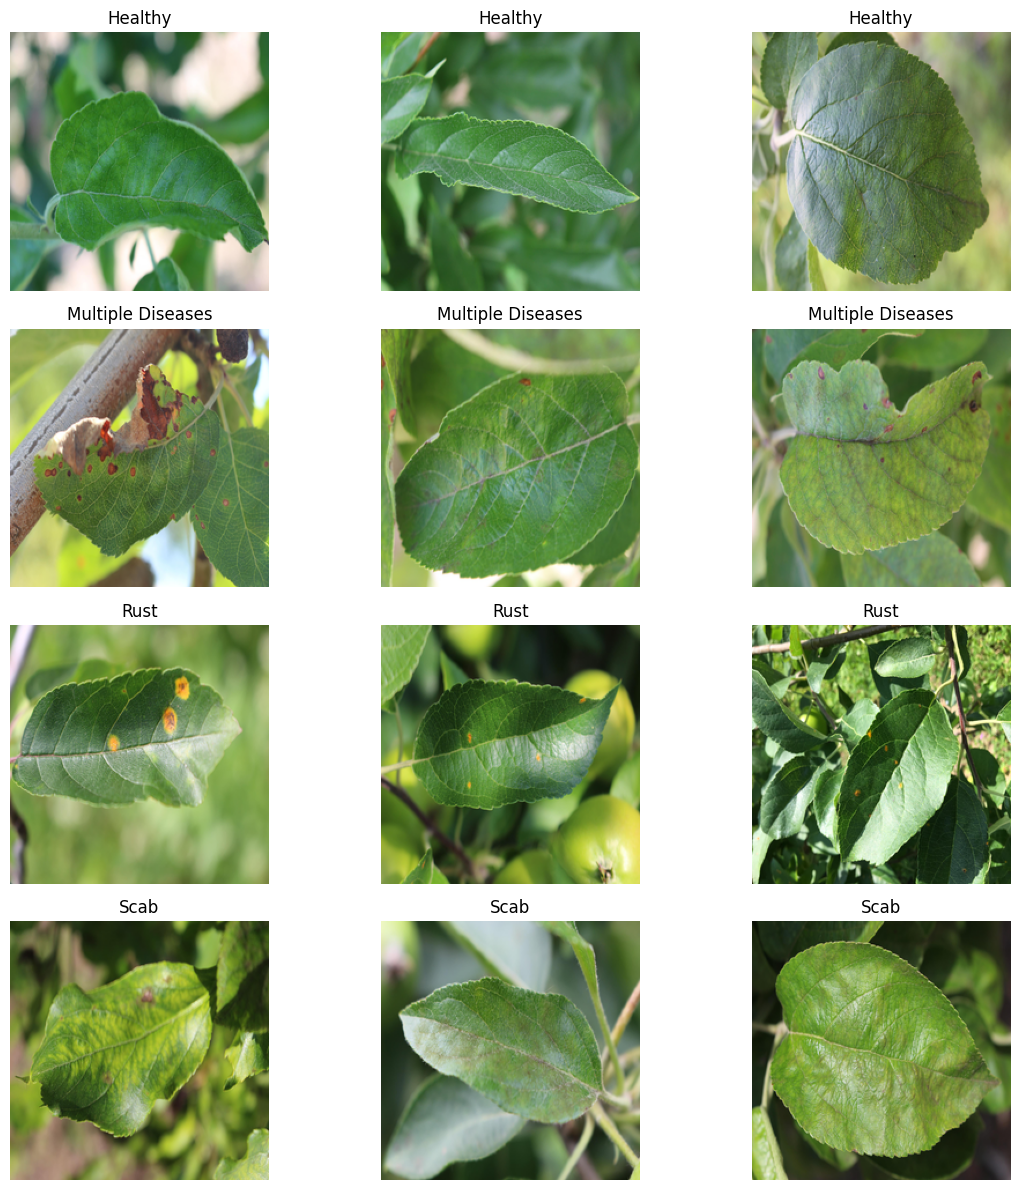


클래스 분포 (%):
  Healthy: 28.3%
  Multiple Diseases: 5.0%
  Rust: 34.2%
  Scab: 32.5%


In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers

from PIL import Image

import os

# Kaggle 데이터 경로

train_csv = '/kaggle/input/competitions/plant-pathology-2020-fgvc7/train.csv'  # 이미지 파일명, 라벨

train_dir = '/kaggle/input/competitions/plant-pathology-2020-fgvc7/images'  # 훈련 이미지 폴더

# 1. CSV 파일에서 이미지 경로 & 라벨 읽기

df = pd.read_csv(train_csv)

print(df.head())  # (image_id, healthy, multiple_diseases, rust, scab)

# 2. 라벨 변환 (원-핫 → 정수)

# CSV에는 [healthy, multiple_diseases, rust, scab] 컬럼이 0/1로 저장됨

# ✅ TODO: 다음 코드를 완성하세요

# 각 행에서 1인 컬럼의 인덱스를 찾아 라벨로 사용

label_cols = ['healthy', 'multiple_diseases', 'rust', 'scab']

# 단계 1: 1인 컬럼명 찾기

y_train = (df[label_cols] == 1).idxmax(axis=1)  # 힌트: 최댓값의 인덱스

# 단계 2: 컬럼명을 정수(0~3)로 변환

y_train = pd.Categorical(y_train, categories=label_cols).codes

print(f"라벨 분포:\n{np.bincount(y_train)}")  # 각 클래스별 개수

# 3. 이미지 로드 (메모리 절약을 위해 축소)

train_images = []

for idx, row in df.iterrows():

    img_path = os.path.join(train_dir, row['image_id'] + '.jpg')

    img = Image.open(img_path).convert('RGB')

    
    # ✅ TODO: 이미지 크기 조정

    # 원본: 1365×1024 → 목표: 224×224


    # (힌트: Image.resize() 메서드 사용)

    img = img.resize((224, 224), Image.LANCZOS)

    

    train_images.append(np.array(img, dtype='float32'))

X_train = np.array(train_images)

print(f"훈련 이미지 크기: {X_train.shape}")  # (N, 224, 224, 3)

# 4. 정규화 (0~255 → 0~1)

X_train = X_train / 255.0

# 5. 시각화: 각 클래스별 샘플 이미지

fig, axes = plt.subplots(4, 3, figsize=(12, 12))

class_names = ['Healthy', 'Multiple Diseases', 'Rust', 'Scab']

for class_idx in range(4):

    # ✅ TODO: 각 클래스의 이미지 인덱스 찾기

    # (힌트: np.where(y_train == class_idx)[0][:3])

    indices = np.where(y_train == class_idx)[0][:3]

    

    for i, idx in enumerate(indices):

        axes[class_idx, i].imshow(X_train[idx])  # 힌트: imshow

        axes[class_idx, i].set_title(class_names[class_idx])

        axes[class_idx, i].axis('off')  # 힌트: axis

plt.tight_layout()

plt.show()

# 6. 클래스 불균형 분석

print(f"\n클래스 분포 (%):")

for i, name in enumerate(class_names):

    pct = 100 * np.sum(y_train == i) / len(y_train)

    print(f"  {name}: {pct:.1f}%")


In [2]:
# 1. Flatten: 224×224×3 이미지 → 150,528 벡터

X_train_flat = X_train.reshape(X_train.shape[0], -1)

print(f"Flatten 후: {X_train_flat.shape}")  # (N, 150528)

# 2. 훈련/검증 분할 (8:2)

X_train_split, X_val, y_train_split, y_val = train_test_split(

    X_train_flat, y_train, 

    test_size=0.2, 

    random_state=42,

    stratify=y_train  # 클래스 비율 유지

)

print(f"훈련: {X_train_split.shape}, 검증: {X_val.shape}")

print(f"훈련 라벨 분포: {np.bincount(y_train_split)}")

print(f"검증 라벨 분포: {np.bincount(y_val)}")

# 3. 정규화 (StandardScaler)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_split)

X_val_scaled = scaler.transform(X_val)

print(f"정규화 후 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}")

# 4. 클래스 가중치 계산 (불균형 해결)

# ✅ TODO: 클래스 가중치 계산하기

# (힌트: sklearn의 compute_class_weight 사용)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(

    'balanced',

    classes=np.unique(y_train_split),

    y=y_train_split

)


Flatten 후: (1821, 150528)
훈련: (1456, 150528), 검증: (365, 150528)
훈련 라벨 분포: [413  73 497 473]
검증 라벨 분포: [103  18 125 119]
정규화 후 평균: -0.0000, 표준편차: 1.0000


In [3]:
# 1. 모델 구축

model = keras.Sequential([

    layers.Dense(512, activation='relu', input_shape=(150528,)),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    

    layers.Dense(256, activation='relu'),

    layers.BatchNormalization(),

    layers.Dropout(0.3),

    

    layers.Dense(128, activation='relu'),

    layers.BatchNormalization(),

    layers.Dropout(0.2),

    

    layers.Dense(64, activation='relu'),

    

    # ✅ TODO: 4가지 클래스를 출력하려면 활성화함수는?

    # (힌트: 이진분류는 sigmoid, 다중분류는 ____)

    layers.Dense(4, activation='softmax')

])

# 2. 모델 컴파일

model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # ✅ TODO: 손실함수를 선택하세요

    # 옵션: 'binary_crossentropy', 'categorical_crossentropy', 'sparse_categorical_crossentropy'

    # (힌트: 라벨이 정수형이므로 sparse가 붙은 것 사용)

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# 3. 모델 요약

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-16 08:30:30.388786: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,247,172 (294.67 MB)

 Trainable params: 77,245,380 (294.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [4]:
# 조기 종료 (과적합 방지)
class_weight_dict = dict(enumerate(class_weights))
early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True

)

# 훈련 (클래스 가중치 적용)

history = model.fit(

    X_train_scaled, y_train_split,

    validation_data=(X_val_scaled, y_val),

    epochs=100,

    batch_size=32,

    # ✅ TODO: 클래스 가중치를 전달하여 불균형 문제 해결

    # (힌트: 파라미터명 = class_weight_dict)

    class_weight=class_weight_dict,

    callbacks=[early_stop],

    verbose=1

)

print(f"\n훈련 완료! 총 {len(history.history['loss'])}개 에포크")

# 훈련 로그 확인

pd.DataFrame(history.history).tail(10)


Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 914ms/step - accuracy: 0.2691 - loss: 1.8134 - val_accuracy: 0.3260 - val_loss: 1.8583
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 899ms/step - accuracy: 0.3548 - loss: 1.4401 - val_accuracy: 0.3068 - val_loss: 1.5593
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 901ms/step - accuracy: 0.3530 - loss: 1.3003 - val_accuracy: 0.3288 - val_loss: 1.4063
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 900ms/step - accuracy: 0.3640 - loss: 1.2738 - val_accuracy: 0.3671 - val_loss: 1.3382
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 893ms/step - accuracy: 0.4056 - loss: 1.1423 - val_accuracy: 0.4027 - val_loss: 1.3407
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 890ms/step - accuracy: 0.4328 - loss: 1.0874 - val_accuracy: 0.3507 - val_loss: 1.3439
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 897ms/step - accuracy: 0.5021 - loss: 1.0303 - val_accuracy: 0.4110 - val_loss: 1.2961
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 932ms/step - accuracy: 0.5439 - loss: 0.9530 - 

,accuracy,loss,val_accuracy,val_loss
14,0.737637,0.535930,0.463014,1.417829
15,0.759615,0.509725,0.487671,1.560178
16,0.754121,0.508003,0.443836,1.588204
17,0.758242,0.518538,0.438356,1.626851
18,0.798077,0.430828,0.476712,1.699851
19,0.825549,0.380302,0.490411,1.736722
20,0.842720,0.356242,0.457534,1.769020
21,0.833791,0.359868,0.460274,1.884913
22,0.872253,0.276411,0.460274,1.868942
23,0.880495,0.271667,0.468493,1.977435


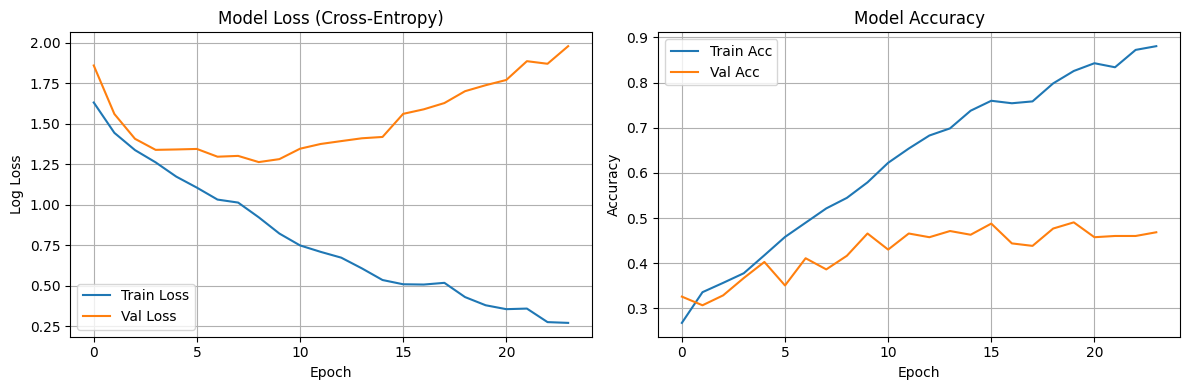

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.4377 - loss: 1.2537

=== 검증 성능 ===
Log Loss: 1.2629
정확도: 0.4164 (41.64%)
목표 정확도: 70% 이상
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step

예측 신뢰도:
  평균: 0.5582
  최소: 0.2890
  최대: 0.9898


In [5]:

# 1. 훈련/검증 손실 & 정확도 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 손실 (Log Loss)

axes[0].plot(history.history['loss'], label='Train Loss')

axes[0].plot(history.history['val_loss'], label='Val Loss')

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Log Loss')

axes[0].set_title('Model Loss (Cross-Entropy)')

axes[0].legend()

axes[0].grid(True)

# 정확도

axes[1].plot(history.history['accuracy'], label='Train Acc')

axes[1].plot(history.history['val_accuracy'], label='Val Acc')

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Accuracy')

axes[1].set_title('Model Accuracy')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

# 2. 최종 성능 평가

val_loss, val_acc = model.evaluate(X_val_scaled, y_val)

print(f"\n=== 검증 성능 ===")

print(f"Log Loss: {val_loss:.4f}")

print(f"정확도: {val_acc:.4f} ({val_acc*100:.2f}%)")

print(f"목표 정확도: 70% 이상")

# 3. 예측 확률 분석

y_val_pred_proba = model.predict(X_val_scaled)

# ✅ TODO: 확률을 클래스 인덱스로 변환하기

# (힌트: softmax 확률 → 가장 높은 확률의 인덱스)

# argmax 함수와 axis 파라미터 사용

y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# 예측 신뢰도 확인

# ✅ TODO: 각 샘플의 최대 확률값을 구하기

confidence = np.max(y_val_pred_proba, axis=1)

print(f"\n예측 신뢰도:")

print(f"  평균: {confidence.mean():.4f}")

print(f"  최소: {confidence.min():.4f}")

print(f"  최대: {confidence.max():.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


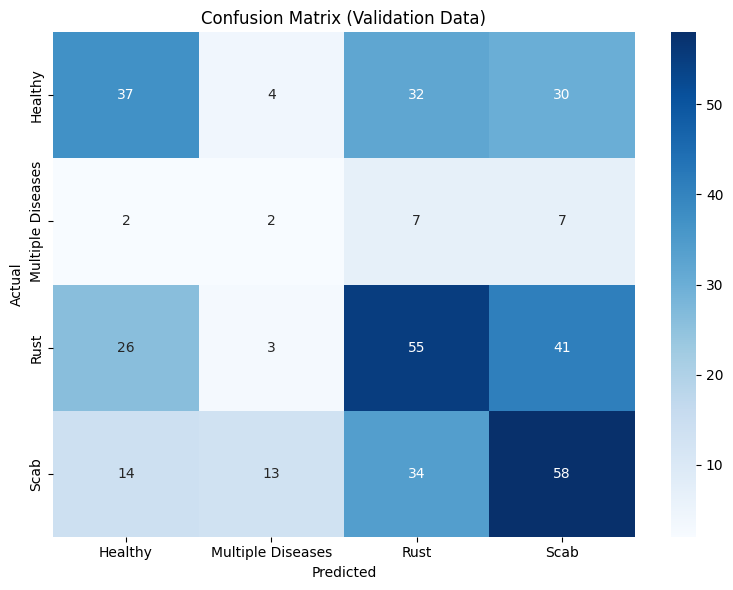


분류 리포트:
                   precision    recall  f1-score   support

          Healthy       0.47      0.36      0.41       103
Multiple Diseases       0.09      0.11      0.10        18
             Rust       0.43      0.44      0.43       125
             Scab       0.43      0.49      0.45       119

         accuracy                           0.42       365
        macro avg       0.35      0.35      0.35       365
     weighted avg       0.42      0.42      0.42       365


클래스별 정확도:
  Healthy: 0.3592 (35.92%)
  Multiple Diseases: 0.1111 (11.11%)
  Rust: 0.4400 (44.00%)
  Scab: 0.4874 (48.74%)

혼동 분석 (실제 vs 예측):
  Healthy → Rust: 32건
  Healthy → Scab: 30건
  Multiple Diseases → Rust: 7건
  Multiple Diseases → Scab: 7건
  Rust → Healthy: 26건
  Rust → Scab: 41건
  Scab → Healthy: 14건
  Scab → Multiple Diseases: 13건
  Scab → Rust: 34건


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

# 1. 예측 (4-class)

y_val_pred_proba = model.predict(X_val_scaled)

# ✅ TODO: 확률을 클래스 인덱스로 변환

y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# 2. 혼동행렬 (4×4) 계산

# ✅ TODO: confusion_matrix 함수 사용

# (힌트: y_val(실제값), y_val_pred(예측값))

class_names = ['Healthy', 'Multiple Diseases', 'Rust', 'Scab']

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,

            xticklabels=class_names,

            yticklabels=class_names)

plt.title('Confusion Matrix (Validation Data)')

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.tight_layout()

plt.show()

# 3. 분류 리포트

print("\n분류 리포트:")

# ✅ TODO: classification_report 함수로 각 클래스별 지표 출력

print(classification_report(y_val, y_val_pred, 

                           target_names=class_names))

# 4. 클래스별 정확도 계산

print(f"\n클래스별 정확도:")

for i, name in enumerate(class_names):

    class_mask = y_val == i

    if class_mask.sum() > 0:

        # ✅ TODO: 각 클래스의 정확도 계산

        # (실제가 i인데 예측도 i인 비율)

        acc = np.sum(y_val_pred[class_mask] == i) / class_mask.sum()

        print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

# 5. 가장 많이 혼동되는 쌍 찾기

print(f"\n혼동 분석 (실제 vs 예측):")

for i in range(4):

    for j in range(4):

        if i != j and cm[i, j] > 5:  # 5개 이상만 표시

            print(f"  {class_names[i]} → {class_names[j]}: {cm[i, j]}건")


In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/plant-pathology-2020-fgvc7/sample_submission.csv
/kaggle/input/competitions/plant-pathology-2020-fgvc7/train.csv
/kaggle/input/competitions/plant-pathology-2020-fgvc7/test.csv
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Test_1743.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Test_262.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Train_1524.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Train_1336.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Train_1461.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Train_1797.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Test_1499.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Train_1170.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Test_1259.jpg
/kaggle/input/competitions/plant-pathology-2020-fgvc7/images/Test_422.jpg
/kaggle/input/competitions/plant-pathology-2